# 0. Libraries

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from feature_engine.imputation import MeanMedianImputer
from feature_engine.selection import DropConstantFeatures, SmartCorrelatedSelection, DropDuplicateFeatures
from feature_engine.outliers import Winsorizer
from feature_engine.transformation import YeoJohnsonTransformer
from sklearn.preprocessing import StandardScaler
import os

import warnings
warnings.filterwarnings('ignore')

# Suppress TensorFlow logs
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

# 1. Reading Clean Dataset:

In [2]:
merged_df = pd.read_csv('./3-DNN_Baseline/V2-merged_df_noOutliers.csv')
merged_df.head(2)

,cid,Smiles,Standard Value,pIC50 Value,nAcid,ALogP,ALogp2,AMR,apol,naAromAtom,...,3d-P2s,3d-E1s,3d-E2s,3d-E3s,3d-Ts,3d-As,3d-Vs,3d-Ks,3d-Ds,QT-pIC50 Value
0,23647975,COc1cc(cc(Cc2cnc(N)nc2N)c1OC)C#CCCCC(O)=O,34.0,7.468521,1,-0.9874,0.974959,55.7857,55.717446,12,...,0.270792,0.568703,0.404621,0.409698,22.863896,123.556813,272.29810,0.506905,1.383022,0.624900
1,5578,COc1cc(Cc2cnc(N)nc2N)cc(OC)c1OC,2722.0,5.565112,0,-1.1990,1.437601,34.9926,43.448274,12,...,0.223644,0.526743,0.420964,0.415681,15.650156,58.403017,129.62338,0.521793,1.363389,-0.538272


In [3]:
merged_df.shape

(873, 2761)

# 2. Important features only

## 2.1. Reading file with Importance of the Descriptors

In [4]:
df_imp = pd.read_csv('./5-Feature_Importance/V2-feature_importance_model_PermImp.csv')
df_imp.head(2)

,Feature,Importance
0,PubchemFP461,0.009318
1,PubchemFP755,0.006300


In [5]:
df_imp.shape

(1858, 2)

## 2.2. Selecting All Features with positive contribution:

In [6]:
df_imp_pos = df_imp[df_imp['Importance']>0]
df_imp_pos.shape[0]

1030

In [7]:
df_imp_pos['Importance'].min()

1.0001948053228738e-06

In [8]:
df_imp_pos['Importance'].max()

0.0093179311212038

In [9]:
features_all_pos = df_imp_pos['Feature'].to_list()

In [10]:
len(features_all_pos)

1030

## 2.3. Positive Features by Groups: 

#### Grouping Features buy Importance and Analyze:


In [11]:
import pandas as pd

# Define the new bin edges based on the new interval
bins = [1e-06, 1e-05, 1e-04, 1e-03, 1e-02]
#bins = [5e-04, 7.5e-04, 1e-03, 5e-03, 7.5e-03, 2e-02]

# Reverse the order of the labels to match the bins
labels = [f"Group_{i+1}" for i in range(len(bins) - 1)][::-1]

# Create the 'Group' column using pd.cut with the new bins and labels
df_imp_pos['Group'] = pd.cut(df_imp_pos['Importance'], bins=bins, labels=labels, right=False)

# Display the DataFrame with the new 'Group' column
df_imp_pos.head()

,Feature,Importance,Group
0,PubchemFP461,0.009318,Group_1
1,PubchemFP755,0.006300,Group_1
2,maxsBr,0.004837,Group_1
3,nFG12HeteroRing,0.003928,Group_1
4,nFG12Ring,0.003861,Group_1


In [12]:
# Filter data for Group_1
features_Group_1 = df_imp_pos[df_imp_pos['Group'] == 'Group_1']
features_Group_2 = df_imp_pos[df_imp_pos['Group'] == 'Group_2']
features_Group_3 = df_imp_pos[df_imp_pos['Group'] == 'Group_3']
features_Group_4 = df_imp_pos[df_imp_pos['Group'] == 'Group_4']
#features_Group_5 = df_imp_pos[df_imp_pos['Group'] == 'Group_5']

In [13]:
features_Group_1_arr = features_Group_1['Feature'].to_list()
features_Group_2_arr = features_Group_2['Feature'].to_list()
features_Group_3_arr = features_Group_3['Feature'].to_list()
features_Group_4_arr = features_Group_4['Feature'].to_list()
#features_Group_5_arr = features_Group_5['Feature'].to_list()

# 3. Splitting Data

In [190]:
# Reset Indexes:
merged_df = merged_df.reset_index(drop=True)

In [191]:
# FOR MODEL

feat_imp = features_Group_1_arr + features_Group_2_arr + features_Group_3_arr

X = merged_df[feat_imp]
y = merged_df['pIC50 Value']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state = 42)

# 4. Missing Data Imputation

In [192]:
# Initialize the imputer with median imputation method
imputer = MeanMedianImputer(imputation_method='median')

# Fit the imputer to the training data
imputer.fit(X_train)

# Transform the training data
X_train = imputer.transform(X_train)
X_test = imputer.transform(X_test)


# 5. Removing Constants and Dublicated

In [193]:
%%time

# Drop constant
drop_const = DropConstantFeatures(tol=0.999)

drop_const.fit(X_train)
X_train = drop_const.transform(X_train)
X_test = drop_const.transform(X_test)

print(X_train.shape)

# Drop duplicates
drop_dup = DropDuplicateFeatures()

drop_dup.fit(X_train)
X_train = drop_dup.transform(X_train)
X_test = drop_dup.transform(X_test)

print(X_train.shape)

(742, 1020)
(742, 1020)
CPU times: user 371 ms, sys: 4.01 ms, total: 375 ms
Wall time: 376 ms


# 6. Outliers

In [194]:
%time

# Initialize Winsorizer transformer
winsorizer = Winsorizer(capping_method='gaussian', tail='both')

# Fit and transform on training data
winsorizer.fit(X_train)

X_train = winsorizer.transform(X_train)
X_test = winsorizer.transform(X_test)

CPU times: user 5 µs, sys: 0 ns, total: 5 µs
Wall time: 8.58 µs


# 7. YeoJohnsonTransformer:

In [195]:
%time

from feature_engine.transformation import YeoJohnsonTransformer

#Randomly sample 3736 rows from df_t25
yeo_trans = YeoJohnsonTransformer()
yeo_trans.fit(X_train)

X_train = yeo_trans.transform(X_train)
X_test = yeo_trans.transform(X_test)

CPU times: user 5 µs, sys: 0 ns, total: 5 µs
Wall time: 9.3 µs


# 8. Scaling:

In [196]:
%time

import pandas as pd
from sklearn.preprocessing import StandardScaler

# Instantiate the StandardScaler
scaler = StandardScaler()

# Fit and transform on the training data
scaler.fit(X_train)

# Scale the training data
X_train_eda = scaler.transform(X_train)
X_test_eda = scaler.transform(X_test)

# Convert the numpy arrays back to DataFrames and assign column names
X_train = pd.DataFrame(X_train_eda, columns=X_train.columns)
X_test = pd.DataFrame(X_test_eda, columns=X_test.columns)

CPU times: user 5 µs, sys: 0 ns, total: 5 µs
Wall time: 9.3 µs


# 9. Augmentation:

In [197]:
# Concatenate X_train and X_test to get the full feature set
X_f = pd.concat([X_train, X_test], axis=0)

# Concatenate y_train and y_test to get the full target variable
y_f = pd.concat([y_train, y_test], axis=0)

## 9.1. Saving Validation dtaa (10% of database before augmentation)

In [198]:
X, X_test_val, y, y_test_val = train_test_split(X_f, y_f, test_size=0.10, random_state = 42)

In [199]:
print(X.shape)
print(y.shape)

(785, 1020)
(785,)


## 9.2. Augmentation of 90% the database

In [200]:
import numpy as np
import pandas as pd

# Set the noise factor (you can adjust this based on the data scale)
noise_factor = 0.01
noise_factor_2 = 0.001

# Create empty lists to store augmented data
X_augmented_list = []
y_augmented_list = []

# Loop over each data point and create four augmented cases per point
for i in range(len(X)):
    # Original row
    X_original = X.iloc[i]
    y_original = y.iloc[i]
    
    # Case 1: Add Gaussian noise
    X_augmented_1 = X_original + np.random.normal(0, noise_factor, X_original.shape)
    
    # Case 2: Add Gaussian noise
    X_augmented_2 = X_original + np.random.normal(0, noise_factor_2, X_original.shape)
    
    # Append all augmented cases and the original target to the lists
    X_augmented_list.append(X_augmented_1)
    X_augmented_list.append(X_augmented_2)
    
    y_augmented_list.append(y_original)
    y_augmented_list.append(y_original)

# Convert lists back to pandas DataFrames
X_augmented = pd.DataFrame(X_augmented_list, columns=X.columns)
y_augmented = pd.Series(y_augmented_list, name=y.name)

# Combine the original and augmented data
X_combined = pd.concat([X, X_augmented], axis=0).reset_index(drop=True)
y_combined = pd.concat([y, y_augmented], axis=0).reset_index(drop=True)

# Check the shapes of the combined data
print("X_combined shape:", X_combined.shape)
print("y_combined shape:", y_combined.shape)

# Check a sample of the augmented data
print(X_combined.head())
print(y_combined.head())






X_combined shape: (2355, 1020)
y_combined shape: (2355,)
   PubchemFP461  PubchemFP755    maxsBr  nFG12HeteroRing  nFG12Ring  \
0     -0.073621     -0.410492 -0.138675         3.402392   3.311758   
1     -0.073621     -0.410492 -0.138675        -0.293911  -0.301954   
2     -0.073621      2.436099 -0.138675        -0.293911  -0.301954   
3     -0.073621     -0.410492 -0.138675        -0.293911  -0.301954   
4     -0.073621     -0.410492 -0.138675        -0.293911  -0.301954   

   PubchemFP193  PubchemFP494      JGI7  maxHBint6  PubchemFP737  ...  \
0     -0.166436     -0.104399 -0.630115   0.705086     -0.488601  ...   
1     -0.166436     -0.104399  0.504487  -0.924472     -0.488601  ...   
2     -0.166436     -0.104399  0.451170   0.649610      2.046659  ...   
3     -0.166436     -0.104399 -0.515206  -0.924472      2.046659  ...   
4     -0.166436     -0.104399 -0.759554  -0.924472     -0.488601  ...   

   SpMax3_Bhv  3d-RDF50u     3d-Tv   SHCsats  maxHBint2    3d-P2s   MLFER_L  

## 9.3. Splitting Augmented data

In [201]:
X_train, X_test, y_train, y_test = train_test_split(X_combined, y_combined, test_size=0.01, random_state = 42)

# 10. Multiple ANN Model (Average of 5 runs)

In [202]:
import numpy as np
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from sklearn.metrics import r2_score, mean_absolute_error

# Initialize variables to store results for test set
y_preds_test = []
maes_test = []
r2_scores_test = []

# Initialize variables to store results for validation set
y_preds_val = []
maes_val = []
r2_scores_val = []

# Run the model 5 times
for i in range(5):
    print(f"Running model {i + 1}")
    # Define the neural network model
    model_1 = Sequential([
        Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
        BatchNormalization(),
        Dropout(0.3),       
        Dense(64, activation='relu'),
        BatchNormalization(),
        Dropout(0.2),
        Dense(32, activation='relu'),
        BatchNormalization(),
        Dropout(0.1),
        Dense(16, activation='relu'),
        BatchNormalization(),
        Dense(1, activation='linear')
    ])

    # Compile the model
    optimizer = Adam(learning_rate=0.0007)
    model_1.compile(
        optimizer=optimizer,
        loss='mean_squared_error',
        metrics=['mae']
    )

    # Apply learning rate reduction on plateau
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=20, min_lr=0.000001)

    # Define the EarlyStopping callback
    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=30,
        restore_best_weights=True
    )

    # Train the model, using X_test_val and y_test_val for validation
    history_improved = model_1.fit(
        X_train,
        y_train,
        batch_size=32,
        epochs=200,  # You can increase this for longer training
        validation_data=(X_test_val, y_test_val),  # Use validation set for validation
        shuffle=True,
        verbose=0,
        callbacks=[reduce_lr, early_stopping]
    )

    # Predict on the actual test set (X_test)
    y_pred_test = model_1.predict(X_test)
    y_preds_test.append(y_pred_test.flatten())

    # Predict on the validation set (X_test_val)
    y_pred_val = model_1.predict(X_test_val)
    y_preds_val.append(y_pred_val.flatten())

    # Calculate MAE and R^2 using the test set
    mae_test = mean_absolute_error(y_test, y_pred_test)
    r2_test = r2_score(y_test, y_pred_test)

    # Calculate MAE and R^2 using the validation set
    mae_val = mean_absolute_error(y_test_val, y_pred_val)
    r2_val = r2_score(y_test_val, y_pred_val)

    # Append MAE and R² for test set to lists
    maes_test.append(mae_test)
    r2_scores_test.append(r2_test)

    # Append MAE and R² for validation set to lists
    maes_val.append(mae_val)
    r2_scores_val.append(r2_val)

    # Delete the model to free up memory before the next iteration
    del model_1

# Convert y_preds_test list to a DataFrame
y_preds_test_df = pd.DataFrame(y_preds_test).T
y_preds_test_df.columns = [f'y_pred_run_{i+1}' for i in range(5)]
y_preds_test_df.index = y_test.index  # Use the same index as y_test

# Convert y_preds_val list to a DataFrame
y_preds_val_df = pd.DataFrame(y_preds_val).T
y_preds_val_df.columns = [f'y_pred_run_{i+1}' for i in range(5)]
y_preds_val_df.index = y_test_val.index  # Use the same index as y_test_val

# Calculate the average y_pred across all runs for test and validation sets
y_preds_test_df['average_y_pred'] = y_preds_test_df.mean(axis=1)
y_preds_val_df['average_y_pred'] = y_preds_val_df.mean(axis=1)

# Add y_test and y_test_val to the DataFrames
y_preds_test_df['y_test'] = y_test
y_preds_val_df['y_test_val'] = y_test_val

# Calculate MAE and R^2 for the average predictions for test and validation sets
average_mae_test = mean_absolute_error(y_test, y_preds_test_df['average_y_pred'])
average_r2_test = r2_score(y_test, y_preds_test_df['average_y_pred'])

average_mae_val = mean_absolute_error(y_test_val, y_preds_val_df['average_y_pred'])
average_r2_val = r2_score(y_test_val, y_preds_val_df['average_y_pred'])

# Create a summary DataFrame for test set
summary_test_df = pd.DataFrame({
    'Run': [f'Run {i+1}' for i in range(5)] + ['Average'],
    'R2': r2_scores_test + [average_r2_test],
    'MAE': maes_test + [average_mae_test]
})

# Create a summary DataFrame for validation set
summary_val_df = pd.DataFrame({
    'Run': [f'Run {i+1}' for i in range(5)] + ['Average'],
    'R2': r2_scores_val + [average_r2_val],
    'MAE': maes_val + [average_mae_val]
})

# Display summary DataFrames
print("Test Set Summary:")
print(summary_test_df)

print("\nValidation Set Summary:")
print(summary_val_df)


Running model 1
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
Running model 2
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
Running model 3
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 996us/step
Running model 4
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 994us/step
Running model 5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
Test Set Summary:
       Run        R2       MAE
0    Run 1  0.809330  0.444948
1    Run 2  0.914302  0.276164
2    Run 3  0.882733  0.341126
3    Run 4  0.882657  0.337547
4    Run 5  0.936104  0.247555
5  Average  0.903622  0.300508

Validation Set Summary:
       Run        R2       MAE
0    Run 1  0.857930  0.363261
1    Run 2  0.848613  0.372217
2    Run 3  0.836782  0.401877
3    Run 4  0.853188  0.379312
4    Run 5  0.852308  0.374554
5  Average  0.870334  0.352041


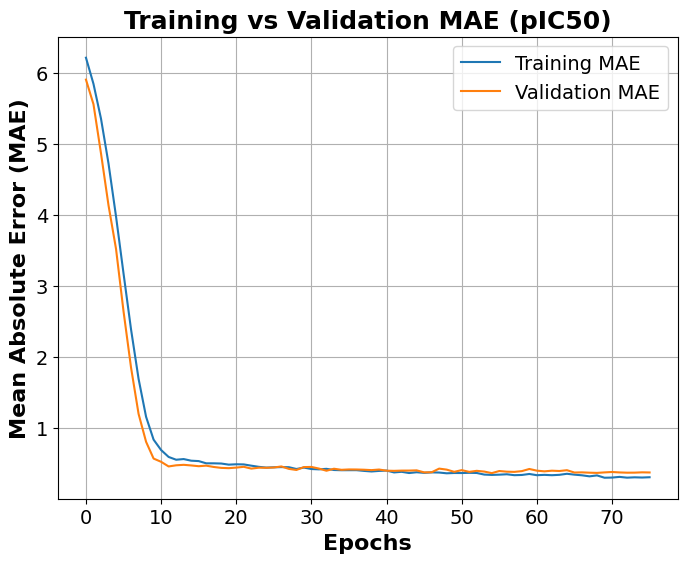

In [203]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

# Plotting MAE for training and validation (test) data
plt.plot(history_improved.history['mae'], label='Training MAE')
plt.plot(history_improved.history['val_mae'], label='Validation MAE')

# Adding title, labels, grid, and legend
plt.title('Training vs Validation MAE (pIC50)', fontsize=18, weight='bold')
plt.xlabel('Epochs', fontsize=16, weight='bold')
plt.ylabel('Mean Absolute Error (MAE)', fontsize=16, weight='bold')
plt.grid(True)
plt.legend(fontsize=14)

# Adjusting tick parameters
plt.tick_params(axis='both', which='major', labelsize=14)

# Display the plot
plt.show()

In [204]:
y_preds_val_df.head()

,y_pred_run_1,y_pred_run_2,y_pred_run_3,y_pred_run_4,y_pred_run_5,average_y_pred,y_test_val
96,5.077713,5.146285,5.324062,4.985079,5.224190,5.151465,5.244125
318,5.709779,5.400370,5.621474,5.987589,5.408631,5.625568,5.853872
692,5.454774,6.135907,6.089284,6.074410,6.158813,5.982638,5.995679
106,6.524003,6.976379,6.884429,6.621428,7.033159,6.807879,6.372634
733,5.626330,5.452322,5.642611,5.748103,5.424643,5.578802,5.455932


In [205]:
y_preds_val_df.head(10)

,y_pred_run_1,y_pred_run_2,y_pred_run_3,y_pred_run_4,y_pred_run_5,average_y_pred,y_test_val
96,5.077713,5.146285,5.324062,4.985079,5.224190,5.151465,5.244125
318,5.709779,5.400370,5.621474,5.987589,5.408631,5.625568,5.853872
692,5.454774,6.135907,6.089284,6.074410,6.158813,5.982638,5.995679
106,6.524003,6.976379,6.884429,6.621428,7.033159,6.807879,6.372634
733,5.626330,5.452322,5.642611,5.748103,5.424643,5.578802,5.455932
268,4.382298,4.315411,4.200600,4.225747,4.941492,4.413109,4.468521
697,6.367352,6.249295,5.922707,6.425696,5.939364,6.180883,6.433563
696,5.423197,5.314242,5.091392,5.303905,5.323861,5.291319,5.795880
34,5.571653,5.191720,5.683979,5.451169,5.408092,5.461323,6.657577
244,7.566031,7.972127,8.164825,7.955767,7.879475,7.907645,7.638272


In [206]:
summary_val_df

,Run,R2,MAE
0,Run 1,0.857930,0.363261
1,Run 2,0.848613,0.372217
2,Run 3,0.836782,0.401877
3,Run 4,0.853188,0.379312
4,Run 5,0.852308,0.374554
5,Average,0.870334,0.352041


# 11. Saveing Output: test for Validation database (saved before augmentation)

In [207]:
y_preds_val_df['Relative_Error_%'] = (y_preds_val_df['average_y_pred'] - y_preds_val_df['y_test_val'])/y_preds_val_df['y_test_val'] * 100
y_preds_val_df.head()

,y_pred_run_1,y_pred_run_2,y_pred_run_3,y_pred_run_4,y_pred_run_5,average_y_pred,y_test_val,Relative_Error_%
96,5.077713,5.146285,5.324062,4.985079,5.224190,5.151465,5.244125,-1.766924
318,5.709779,5.400370,5.621474,5.987589,5.408631,5.625568,5.853872,-3.900044
692,5.454774,6.135907,6.089284,6.074410,6.158813,5.982638,5.995679,-0.217502
106,6.524003,6.976379,6.884429,6.621428,7.033159,6.807879,6.372634,6.829912
733,5.626330,5.452322,5.642611,5.748103,5.424643,5.578802,5.455932,2.252038


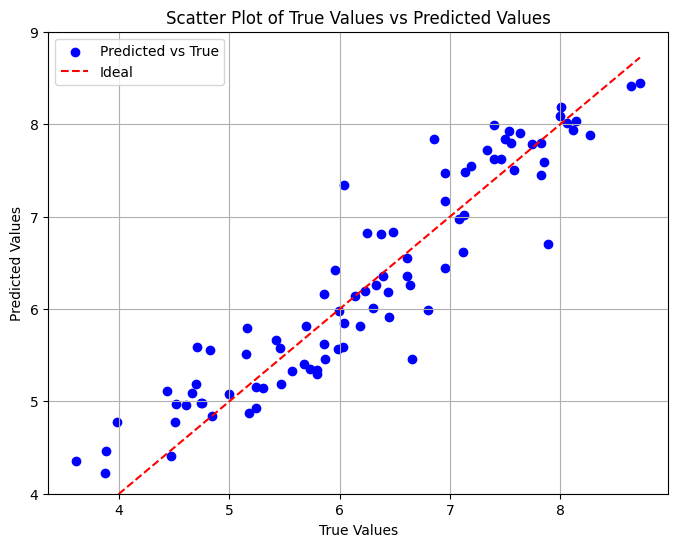

In [208]:
import matplotlib.pyplot as plt
import numpy as np

# Creating the scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(y_preds_val_df['y_test_val'], y_preds_val_df['average_y_pred'], color='blue', label='Predicted vs True')

# Adding the red line representing the ideal case (y = x)
min_val = min(y_preds_val_df['y_test_val'].min(), y_preds_val_df['average_y_pred'].min())
max_val = max(y_preds_val_df['y_test_val'].max(), y_preds_val_df['average_y_pred'].max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Ideal')

# Limiting the y-axis to the range [4, 9]
plt.ylim(4, 9)

# Adding title, labels, grid, and legend
plt.title('Scatter Plot of True Values vs Predicted Values')
plt.xlabel('True Values')
plt.ylabel('Predicted Values')
plt.grid(True)
plt.legend()
plt.show()


In [209]:
# Save the updated DataFrame to a CSV file
y_preds_val_df.to_csv('V2-output_model_aug_gr123.csv', index=False)

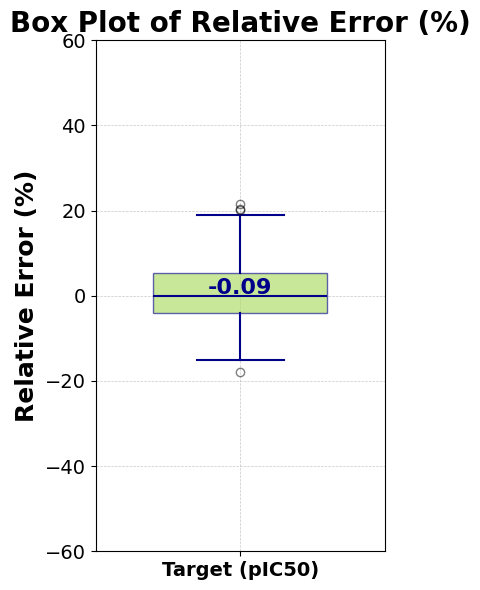

In [210]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

log_target_test = y_preds_val_df['Relative_Error_%']

# Increase the width of the figure to make the plot wider
plt.figure(figsize=(4, 6))

# Create the box plot with adjusted box width and frame thickness
box = plt.boxplot([log_target_test], 
                  vert=True, patch_artist=True, widths=0.6,  # Increase the box width
                  boxprops=dict(facecolor='none', color='darkblue', linewidth=1),  # Thinner box frame
                  medianprops=dict(color='darkblue', linewidth=1.5), 
                  whiskerprops=dict(color='darkblue', linewidth=1.5),
                  capprops=dict(color='darkblue', linewidth=1.5), 
                  flierprops=dict(marker='o', color='red', alpha=0.5))

# Change the color of the box
colors = ['#a6d854']
for box_patch, color in zip(box['boxes'], colors):
    box_patch.set(facecolor=color, alpha=0.6)

# Add grid lines
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

# Add a title and labels with custom font sizes
plt.title('Box Plot of Relative Error (%)', fontsize=20, weight='bold')
plt.ylabel('Relative Error (%)', fontsize=18, weight='bold')
plt.xticks([1], ['Target (pIC50)'], fontsize=18, weight='bold')

# Adding median value as text, positioned above the box plot
median = box['medians'][0].get_ydata()[0]
plt.text(1, median + 2, f'{median:.2f}', horizontalalignment='center', color='darkblue', weight='semibold', va='center', fontsize=16)

# Enhance the appearance of the plot
plt.tick_params(axis='both', which='major', labelsize=14)
plt.ylim(-60, 60)  # Set y-axis limit
plt.tight_layout()

# Display the plot
plt.show()
